# Forman-Ricci curvature transformation


## Context

We would like to compute diffusion distance between graphs (GDD) with the method of Hammond et al. (2013), but using Forman-Ricci curvature values as edge weights in this computation. However, FRC can take both positive and negative values, and for GDD computation we need positive weights. 

In this notebook, I test the submodule `modeling/transform_curvature.py` that applies the proposed transformation to FRCs computed for a graph

## Curvature transformation

The basic idea is to replace the original curvature values by a single global transform applied uniformly across the full collection of curvatures. If the original curvature is denoted by $c$, define

$$
c^{\star} = -c,
$$

and then transform via

$$
\tilde c = a c^{\star} + b = -a c + b,
$$

where $a > 0$ and $b$ are constants chosen once and then used for all values.

## Notes
- Parameters must be fitted globally (for the full collection of curvatures of all the networks considered in the experiments) 
- I flip the sign because more negative Forman-Ricci curvature corresponds to more conductance -- we want larger weights for more negative FRC.
- The transformation preserves ordering (after sign flip)
- The transformation preserves strict positivity -- so in the functions I secure for the smallest weight not becoming zero.
- The transformation function includes the option of rescaling the curvatures - this is not to be done for FRc as it would make the results not interpretable. Therefore the range to rescale to is set to `None` by default. 


## Notebook settings

In [1]:
verbose = True

## Imports

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from pathlib import Path

from hyphi.io_brainhack import load_all_kuramoto_adjacencies

from hyphi.modeling.graph_curvatures import compute_frc, extract_curvatures

from hyphi.modeling.transform_curvature import (
    as_1d_float_array,
    fit_global_positive_linear_transform,
    transform_curvature_collection,
    check_all_positive,
    attach_edge_weights_to_graph,
)
from hyphi.modeling.curvatures import (
    compute_laplacian_matrix,
    heat_kernel_distance,
)

from hyphi.modeling.GDD_FRc_helpers import (
    compute_global_curvature_stats,
    compute_frc_bundles_from_adjacencies,
    compute_successive_gdd,
)

from hyphi.visualization.GDD_FRc_visualization import (
    plot_weight_distributions_by_matrix,
    plot_successive_gdd,
)


***********************************************************************************************
***********************************************************************************************

                                             HyPhi                                             

***********************************************************************************************
***********************************************************************************************

Current working dir:	C:\Users\Lenovo\Desktop\Brainhack26_HyPhi\HyPhi\code\notebooks
New working dir: 'C:\Users\Lenovo\Desktop\Brainhack26_HyPhi'



## Paths

In [3]:
kuramoto_base_dir = Path("HyPhi") / "data" / "connectome"
kuramoto_indices = range(1, 9)
kuramoto_suffix = "connectome_kuramoto.pkl"


## Trying to work with all Kuramoto matrices at once

[1] loaded HyPhi\data\connectome\1_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
[2] loaded HyPhi\data\connectome\2_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
[3] loaded HyPhi\data\connectome\3_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
[4] loaded HyPhi\data\connectome\4_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
[5] loaded HyPhi\data\connectome\5_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
[6] loaded HyPhi\data\connectome\6_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
[7] loaded HyPhi\data\connectome\7_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
[8] loaded HyPhi\data\connectome\8_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
[1] computed FRC bundle
   path: HyPhi\data\connectome\1_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
   number of curvature values: 11628
[2] computed FRC bundle
   path: HyPhi\data\connectome\2_connectome_kuramoto.pkl
   adjacency shape: (152, 152)
   number of curvat

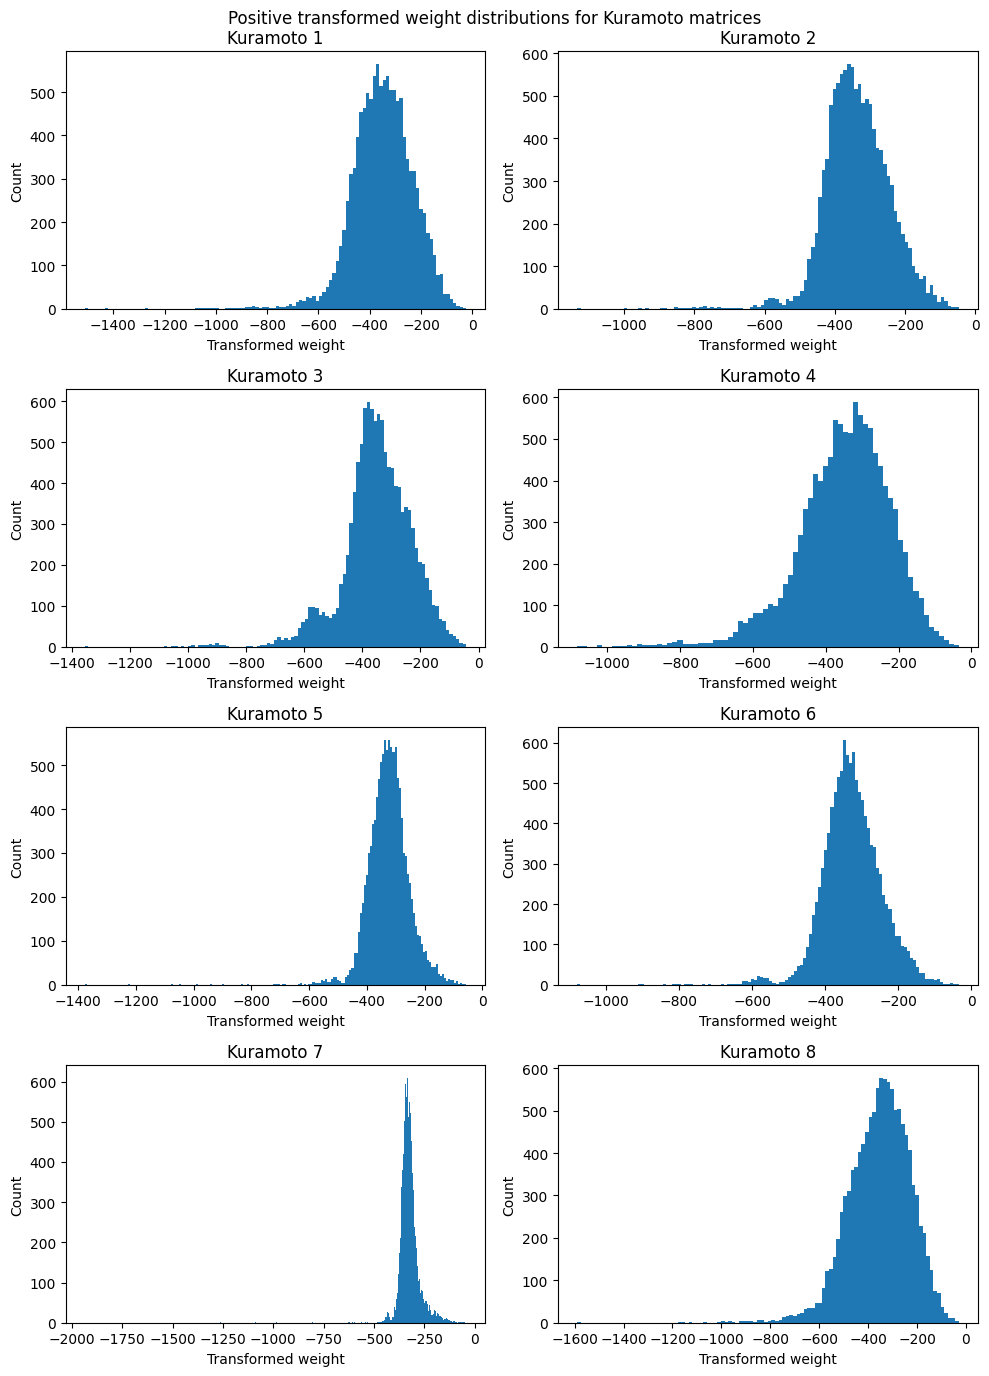

In [4]:
kuramoto_loaded = load_all_kuramoto_adjacencies(
    indices=kuramoto_indices,
    base_dir=kuramoto_base_dir,
    suffix=kuramoto_suffix,
    weight_key="weight",
    symmetrize=False,
    verbose=verbose,
)

kuramoto_results = compute_frc_bundles_from_adjacencies(
    kuramoto_loaded["adjacencies"],
    method="1d",
    paths=kuramoto_loaded["paths"],
    verbose=verbose,
)

# variables extracted for convenience
kuramoto_paths = {k: v["path"] for k, v in kuramoto_results.items()}
kuramoto_adjacencies = {k: v["adjacency"] for k, v in kuramoto_results.items()}
kuramoto_graphs = {k: v["graph"] for k, v in kuramoto_results.items()}
kuramoto_frc_graphs = {k: v["graph_frc"] for k, v in kuramoto_results.items()}
kuramoto_edge_curvatures = {k: v["edge_curvatures"] for k, v in kuramoto_results.items()}
kuramoto_curvatures = {k: v["curvatures"] for k, v in kuramoto_results.items()}

# summarize the global curvature distribution
global_curvature_stats = compute_global_curvature_stats(kuramoto_curvatures)

fig = plot_weight_distributions_by_matrix(
    kuramoto_curvatures,
    bins="fd",
    ncols=2,
    main_title="Positive transformed weight distributions for Kuramoto matrices",
)
# plt.show()

if verbose:
    print(" ")
    print("Global curvature statistics across Kuramoto matrices 1..8")
    print("mean  :",  global_curvature_stats["mean"])
    print("std   :",  global_curvature_stats["std"])
    print("median:",  global_curvature_stats["median"])
    print("mad   :",  global_curvature_stats["mad"])
    plt.show()

kuramoto_results = load_all_kuramoto_results(
    indices=kuramoto_indices,
    base_dir=kuramoto_base_dir,
    suffix=kuramoto_suffix,
    weight_key="weight",
    directed=False,
    fill_diagonal=False,
    frc_method="1d",
    verbose=verbose,
)

# variables extracted for convenience
kuramoto_paths = {k: v["path"] for k, v in kuramoto_results.items()}
kuramoto_adjacencies = {k: v["adjacency"] for k, v in kuramoto_results.items()}
kuramoto_graphs = {k: v["graph"] for k, v in kuramoto_results.items()}
kuramoto_frc_graphs = {k: v["graph_frc"] for k, v in kuramoto_results.items()}
kuramoto_edge_curvatures = {k: v["edge_curvatures"] for k, v in kuramoto_results.items()}
kuramoto_curvatures = {k: v["curvatures"] for k, v in kuramoto_results.items()}

# summarize the global curvature distribution
global_curvature_stats = compute_global_curvature_stats(kuramoto_curvatures)

fig = plot_weight_distributions_by_matrix(
    kuramoto_curvatures,
    bins="fd",
    ncols=2,
    main_title="Positive transformed weight distributions for Kuramoto matrices",
)
# plt.show()

if verbose:
    print(" ")
    print("Global curvature statistics across Kuramoto matrices 1..8")
    print("mean  :",  global_curvature_stats["mean"])
    print("std   :",  global_curvature_stats["std"])
    print("median:",  global_curvature_stats["median"])
    print("mad   :",  global_curvature_stats["mad"])
    plt.show()

Global linear transform parameters
sign: -1.0
scale: 1.0
shift: -23.26468690022001
raw_global_min: -1936.7217216657732
raw_global_max: -23.26468690122001
signed_global_min: 23.26468690122001
signed_global_max: 1936.7217216657732
transformed_global_min: 1.000000082740371e-09
transformed_global_max: 1913.457034765553

Positivity check
[1] min=1e-09, max=1488.32, all_positive=True
[2] min=23.8014, max=1110.47, all_positive=True
[3] min=18.686, max=1332, all_positive=True
[4] min=11.6872, max=1059.44, all_positive=True
[5] min=32.5747, max=1353.19, all_positive=True
[6] min=10.7618, max=1055.97, all_positive=True
[7] min=18.0085, max=1913.46, all_positive=True
[8] min=6.57552, max=1566.88, all_positive=True


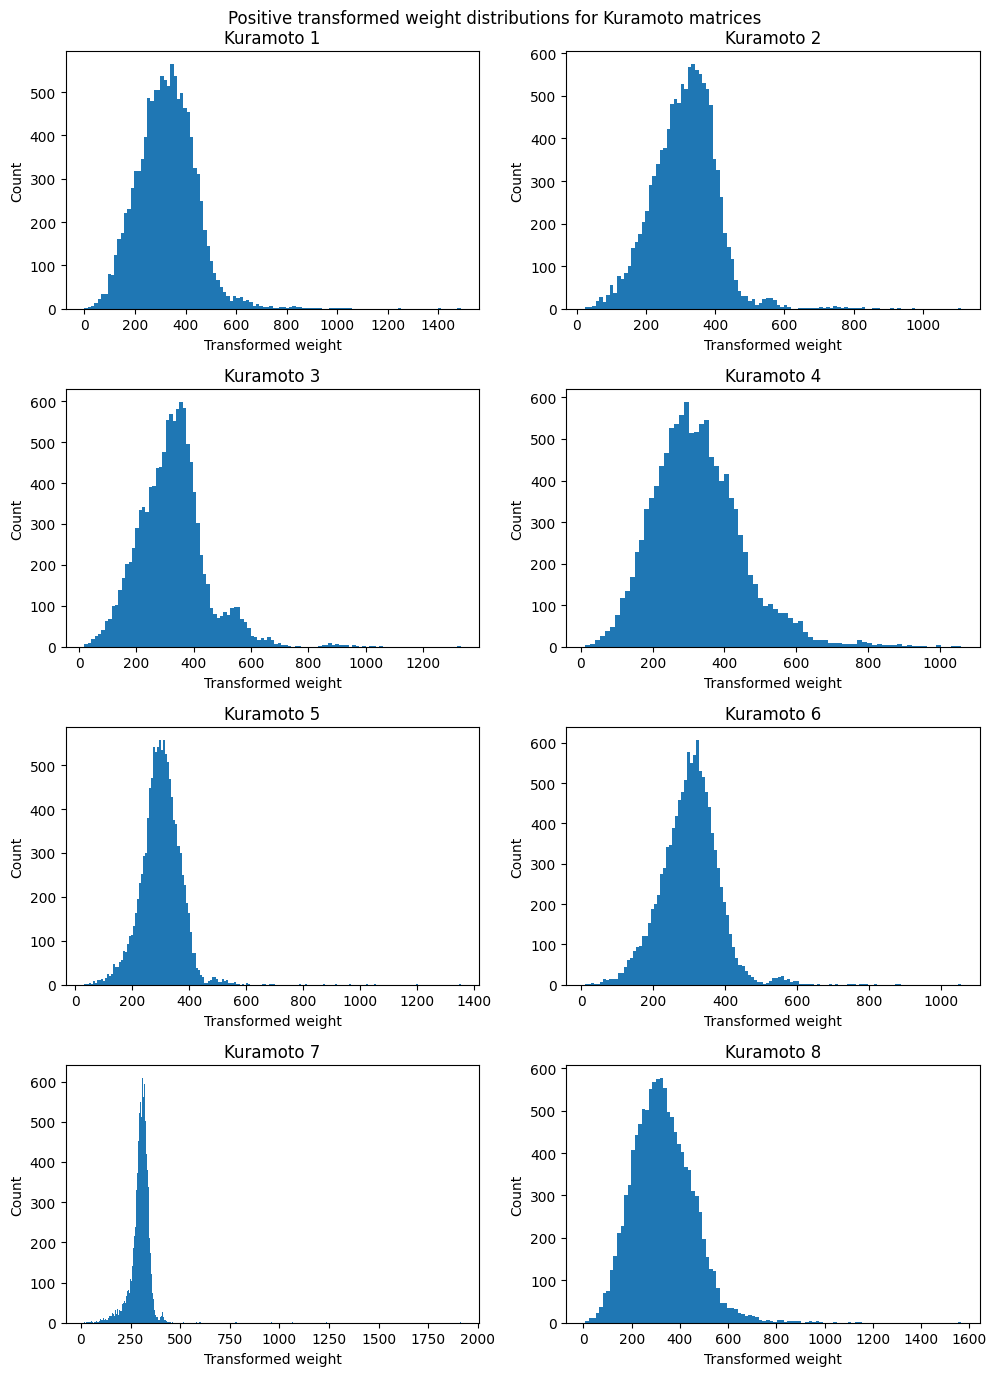

In [5]:
global_linear_params = fit_global_positive_linear_transform(
    kuramoto_curvatures,
    flip_sign=True,
    rescale = None, 
)

print("Global linear transform parameters")
for key, value in global_linear_params.items():
    print(f"{key}: {value}")

# transform curvature arrays
kuramoto_positive_curvatures = transform_curvature_collection(
    kuramoto_curvatures,
    global_linear_params,
)

# transform edge-curvature dictionaries
kuramoto_positive_edge_weights = transform_curvature_collection(
    kuramoto_edge_curvatures,
    global_linear_params,
)

# store everything back into kuramoto_results
for k in kuramoto_results:
    kuramoto_results[k]["positive_weight_params"] = global_linear_params
    kuramoto_results[k]["positive_curvatures"] = kuramoto_positive_curvatures[k]
    kuramoto_results[k]["positive_edge_weights"] = kuramoto_positive_edge_weights[k]

# Optional: create graph copies with the transformed weights attached
kuramoto_positive_weight_graphs = {
    k: attach_edge_weights_to_graph(
        kuramoto_frc_graphs[k],
        kuramoto_positive_edge_weights[k],
        attr_name="positive_weight",
    )
    for k in kuramoto_frc_graphs
}

# Sanity check: all transformed weights should now be strictly positive
positivity_summary = check_all_positive(kuramoto_positive_curvatures)

print("\nPositivity check")
for k, stats in positivity_summary.items():
    print(
        f"[{k}] min={stats['min']:.6g}, "
        f"max={stats['max']:.6g}, "
        f"all_positive={stats['all_positive']}"
    )

fig = plot_weight_distributions_by_matrix(
    kuramoto_positive_curvatures,
    bins="fd",
    ncols=2,
    main_title="Positive transformed weight distributions for Kuramoto matrices",
)
plt.show()

## Test Laplacian and GDD computation on 2 matrices

In [6]:
L_kuramoto_1 = compute_laplacian_matrix(kuramoto_positive_weight_graphs[1], g_weight="positive_weight")
L_kuramoto_2 = compute_laplacian_matrix(kuramoto_positive_weight_graphs[2], g_weight="positive_weight")
dist = heat_kernel_distance(L_kuramoto_1, L_kuramoto_2)
if verbose:
    print(dist)

1.4551909328602287e-09


## Compute GDD as function of time step

In the graph below: 

$Value(t-1) =  GDD(t) - GDD(t-1)$

where $t$ - Kuramoto matrix index. 

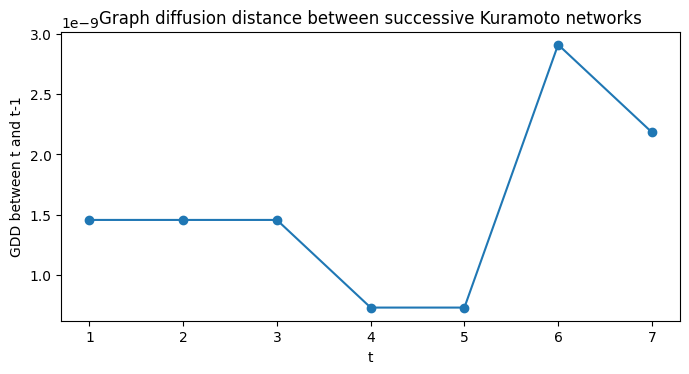

In [7]:
successive_gdd = compute_successive_gdd(
    kuramoto_positive_weight_graphs,
    weight_attr="positive_weight",
)

#print(successive_gdd)
plot_successive_gdd(successive_gdd)